In [1]:
import pandas as pd

df = pd.read_csv("../data/raw_dataset.csv")

df.head()

,project_id,project_type,project_scale,project_duration_years,complexity_index,initial_investment,tax_rate,risk_index,year,inflation_rate,market_growth_rate,revenue,operating_cost,capex,working_capital,cash_flow
0,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,1,0.06,0.01,25091835.95,18278559.30,5887041.96,2220759.40,-2395752.07
1,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,2,0.07,0.04,31515722.37,21472504.85,2156997.60,2711995.95,5588259.78
2,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,3,0.09,0.08,47433995.67,36251329.00,4425897.72,4174260.40,3249734.67
3,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,4,0.05,0.06,48164969.53,35344119.92,1939175.23,4229398.99,8667076.68
4,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,5,0.06,0.12,67876067.92,49986826.23,4078154.71,5751746.19,9068670.71


In [2]:
target = "cash_flow"

features = [
    "project_type",
    "project_scale",
    "project_duration_years",
    "complexity_index",
    "initial_investment",
    "tax_rate",
    "risk_index",
    "year",
    "inflation_rate",
    "market_growth_rate"
]

X = df[features]
y = df[target]

In [4]:
from sklearn.model_selection import train_test_split

project_ids = df["project_id"].unique().to_numpy()

train_projects, test_projects = train_test_split(
    project_ids,
    test_size=0.20,
    random_state=42
)

train_mask = df["project_id"].isin(train_projects)
test_mask = df["project_id"].isin(test_projects)

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

print("Training projects:", len(train_projects))
print("Testing projects:", len(test_projects))
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training projects: 400
Testing projects: 100
Training rows: 2620
Testing rows: 645


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = [
    "project_type",
    "project_scale"
]

numerical_features = [
    "project_duration_years",
    "complexity_index",
    "initial_investment",
    "tax_rate",
    "risk_index",
    "year",
    "inflation_rate",
    "market_growth_rate"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            StandardScaler(),
            numerical_features
        )
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [6]:
from sklearn.preprocessing import StandardScaler

y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(
    y_train.to_numpy().reshape(-1, 1)
).ravel()

y_test_scaled = y_scaler.transform(
    y_test.to_numpy().reshape(-1, 1)
).ravel()

In [7]:
from sklearn.neural_network import MLPRegressor

ann_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42
)

In [8]:
ann_model.fit(
    X_train_processed,
    y_train_scaled
)

print("ANN training completed.")

ANN training completed.


In [9]:
y_pred_scaled = ann_model.predict(X_test_processed)

y_pred = y_scaler.inverse_transform(
    y_pred_scaled.reshape(-1, 1)
).ravel()

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MLP Results: ")

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MLP Results: 
MAE : 5345306.073553937
RMSE: 7750627.309150882
R²  : 0.3673528602267543


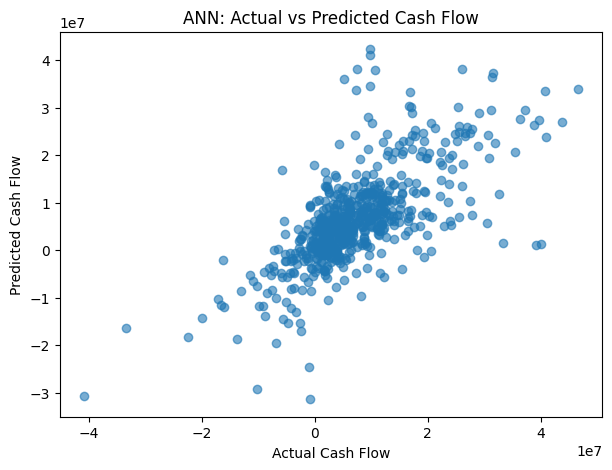

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Cash Flow")
plt.ylabel("Predicted Cash Flow")
plt.title("ANN: Actual vs Predicted Cash Flow")

plt.show()

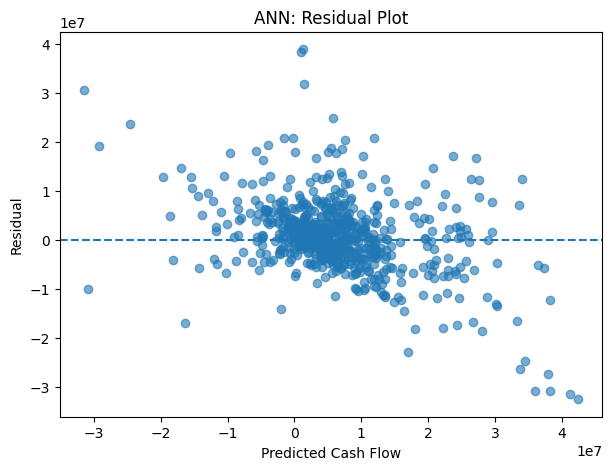

In [14]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))

plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Cash Flow")
plt.ylabel("Residual")
plt.title("ANN: Residual Plot")

plt.show()

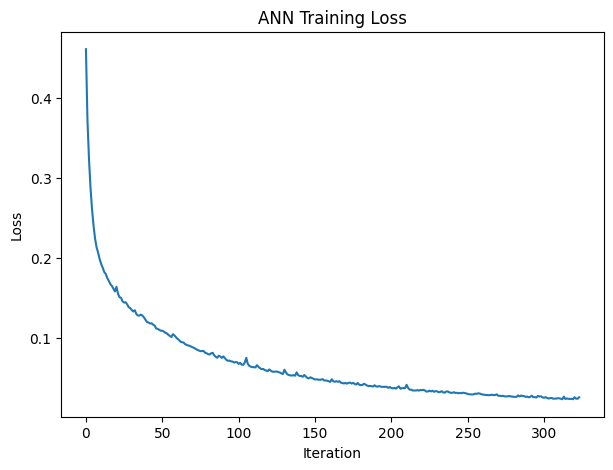

In [15]:
plt.figure(figsize=(7, 5))

plt.plot(ann_model.loss_curve_)

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("ANN Training Loss")

plt.show()

In [16]:
ann_result = {
    "model": "ANN / MLP",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
}

print(ann_result)

{'model': 'ANN / MLP', 'MAE': 5345306.073553937, 'RMSE': np.float64(7750627.309150882), 'R2': 0.3673528602267543}
